# 데이터분석 개요 및 기초 통계 Day 1

| 항목 | 내용 |
|---|---|
| 교육일자 | 2026년 7월 20일 |
| 과정 | SKALA 4기 데이터분석 및 AIOps |
| 메인교수 | 이은호 |
| 실습교수 | 김영희 |

## 학습 목표

① 변수의 유형과 분석 단위를 구분한다.<br>
② 탐색적 데이터 분석의 기본 절차를 수행한다.<br>
③ 평균, 중앙값, 분산, 표준편차, 사분위수와 왜도를 계산하고 해석한다.<br>
④ 표준점수로 서로 다른 분포의 값을 비교한다.<br>

## 실습 진행 방법

① 환경 설정 셀을 먼저 실행한다.<br>
② 각 실습의 `TODO` 부분을 작성한다.<br>
③ 실행 결과를 확인한 뒤 정답 셀과 비교한다.<br>
④ 심화 실습은 기본 실습을 마친 뒤 선택해서 수행한다.<br>


In [66]:
# 환경 설정: 이 셀을 먼저 실행합니다.
!pip install -q koreanize-matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib
from scipy import stats

np.random.seed(42)
plt.rcParams["figure.figsize"] = (8, 4)

print("환경 설정 완료")
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)


환경 설정 완료
NumPy: 2.0.2
pandas: 2.2.2


## 1. 데이터 분석 개요

데이터 분석은 수집한 데이터에서 의미 있는 정보를 찾아 의사결정에 활용하는 과정이다.

### 1.1 데이터 분석의 네 가지 유형

| 유형 | 핵심 질문 | 예시 |
|---|---|---|
| 기술적 (Descriptive) | 무엇이 일어났는가 | 지난달 매출은 10억 원이다 |
| 진단적 (Diagnostic) | 왜 일어났는가 | 신규 고객 증가가 매출 상승의 원인이다 |
| 예측적 (Predictive) | 앞으로 무엇이 일어날까 | 다음 달 매출은 11억 원으로 예상된다 |
| 처방적 (Prescriptive) | 무엇을 해야 하는가 | 광고 예산의 60%를 A 채널에 배정한다 |

### 1.2 DIKW 흐름

**D**ata(가공되지 않은 사실) → **I**nformation(의미) → **K**nowledge(활용) → **W**isdom(행동 원리)

### 확인 문제

다음 문장이 어떤 분석 유형에 해당하는지 판단한다.

1. 이번 분기 이탈 고객 수는 1,200명이다.
2. 재고를 지금 20% 줄이는 것이 적절하다.
3. 이탈 원인은 배송 지연 관련 불만 증가이다.
4. 다음 달 이탈 고객은 약 1,500명으로 예상된다.

<details>
<summary>정답 확인</summary>

1번 기술 분석, 2번 처방 분석, 3번 진단 분석, 4번 예측 분석
</details>


## 2. 변수와 데이터 구조

### 2.1 핵심 개념

| 용어 | 설명 |
|---|---|
| 변수 | 분석 대상의 속성을 나타내는 열 |
| 값 | 변수에 저장된 실제 측정 결과 |
| 관측치 | 분석 대상 하나를 나타내는 행 |
| 범주형 변수 | 종류나 집단을 구분하는 변수 |
| 연속형 변수 | 수치의 크기와 차이에 의미가 있는 변수 |
| 종속변수 Y | 예측하거나 설명하려는 값 |
| 독립변수 X | Y를 설명하거나 예측하는 데 사용하는 값 |

숫자로 표현되어도 학년, 등급, 우편번호처럼 계산 결과에 의미가 없으면 범주형으로 다룬다.


In [67]:
# ── 시연 : iris 데이터셋의 구조 훑어보기 ──────────────────
# iris 데이터는 붓꽃 150송이의 측정값으로 구성됩니다.
iris = sns.load_dataset("iris")

print("행(관측치) × 열(변수) :", iris.shape)
print("\n변수 목록과 자료형:")
print(iris.dtypes)          # float64 -> 연속형 후보 / object -> 범주형 후보
iris.head()                 # 한 행 = 붓꽃 한 송이 (분석 단위)


행(관측치) × 열(변수) : (150, 5)

변수 목록과 자료형:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### 2.2 기초 실습: 변수 유형 구분

다음 변수를 범주형 또는 연속형으로 구분한다.

| 변수 | 값 예시 |
|---|---|
| 학년 | 1, 2, 3 |
| 연령 | 18, 19, 20 |
| 연령대 | 10대, 20대 초반 |
| 언어 점수 | 0부터 100 |
| 언어 등급 | 1부터 9 |

#### 수행 절차

① 각 변수에서 평균을 계산하는 것이 의미 있는지 판단한다.<br>
② `answer_1_1` 딕셔너리의 빈 문자열을 채운다.<br>
③ 정답 셀과 비교한다.


In [68]:
# TODO: "범주형" 또는 "연속형" 문자열을 채우세요
answer_1_1 = {
    "학년":      "categorical",     # 1,2,3,NA — 수치 간 양적 의미가 있을까?
    "연령":      "continuous",
    "연령대":    "categorical",
    "언어 점수": "continuous",
    "언어 등급": "categorical",
}
answer_1_1


{'학년': 'categorical',
 '연령': 'continuous',
 '연령대': 'categorical',
 '언어 점수': 'continuous',
 '언어 등급': 'categorical'}

In [69]:
#@title 정답 확인 { display-mode: "form" }
answer_1_1 = {
    "학년":      "범주형",   # 1→2→3 은 '구분'일 뿐, 2학년이 1학년의 2배가 아님 (순서척도)
    "연령":      "연속형",   # 간격,비율이 산술적 의미를 가짐 (비율척도)
    "연령대":    "범주형",   # 구간으로 묶는 순간 범주가 됨 (순서척도)
    "언어 점수": "연속형",   # 0~100 연속 수치 (구간척도)
    "언어 등급": "범주형",   # 1등급~9등급 — 숫자 옷을 입은 '순서' (순서척도)
}
print("핵심: 숫자로 표기됐다고 연속형이 아니다. '평균을 내는 게 의미 있는가?'로 판별!")
answer_1_1


핵심: 숫자로 표기됐다고 연속형이 아니다. '평균을 내는 게 의미 있는가?'로 판별!


{'학년': '범주형', '연령': '연속형', '연령대': '범주형', '언어 점수': '연속형', '언어 등급': '범주형'}

### 2.3 응용 실습: X와 Y, 분석 단위 정하기

`tips` 데이터로 팁 금액을 예측하는 분석을 설계한다.

#### 수행 내용

① 종속변수 Y를 선택한다.<br>
② 독립변수 X 후보를 세 개 이상 선택하고 변수 유형을 표시한다.<br>
③ 한 행이 무엇을 의미하는지 한 문장으로 작성한다.


In [70]:
tips = sns.load_dataset("tips")
display(tips.head(3))
print(tips.dtypes)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3


total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object


In [71]:
# TODO: 아래 변수를 채우세요
target_y  = "tip"        # 예측하려는 값 (컬럼명)
features  = {
    "total_bill": "연속형",
    "size": "연속형",
    "day": "범주형",
    "time": "범주형",
    "smoker": "범주형",
}        # 예: {"컬럼명": "연속형", ...}  3개 이상
unit      = "한 행 = 식사 1건"        # 분석 단위 한 문장
for i in range(len(features)):
    print(f"Y = {target_y}, X = {list(features.keys())[i]}, 분석 단위 = {unit}")

Y = tip, X = total_bill, 분석 단위 = 한 행 = 식사 1건
Y = tip, X = size, 분석 단위 = 한 행 = 식사 1건
Y = tip, X = day, 분석 단위 = 한 행 = 식사 1건
Y = tip, X = time, 분석 단위 = 한 행 = 식사 1건
Y = tip, X = smoker, 분석 단위 = 한 행 = 식사 1건


In [72]:
#@title 정답 확인 { display-mode: "form" }
target_y = "tip"                       # 알고자 하는 값 = 팁 금액 (연속형 -> 회귀 문제)
features = {
    "total_bill": "연속형",            # 식사 금액 — 팁과 가장 직결될 가능성
    "size":       "연속형",            # 일행 수 (정수지만 산술 의미 있음 -> 연속형 취급 가능)
    "day":        "범주형",            # 요일 (명목척도)
    "time":       "범주형",            # 점심/저녁 (이진척도)
    "smoker":     "범주형",            # 흡연석 여부 (이진척도)
}
unit = "한 행 = 식사 1건(테이블 1팀의 결제 1회)"

#  해석 포인트
# Y가 연속형이면 회귀, 범주형이면 분류 문제로 볼 수 있습니다.
#  - size 처럼 정수형 변수는 목적에 따라 연속/범주 어느 쪽으로도 다룰 수 있음
print(f"Y = {target_y} | X 후보 {len(features)}개 | 분석 단위: {unit}")


Y = tip | X 후보 5개 | 분석 단위: 한 행 = 식사 1건(테이블 1팀의 결제 1회)


### 2.4 심화 실습: 거래 데이터를 고객 단위로 변환하기

원천 데이터의 한 행은 거래 한 건이지만 분석 단위는 고객 한 명이다. `groupby()`와 `agg()`를 사용해 고객 단위 데이터로 변환한다.

#### 생성할 변수

- 총구매액: 고객별 금액 합계
- 구매건수: 고객별 거래 횟수
- 고객등급: 구매건수가 2건 이상이고 총구매액이 500 이상이면 A, 아니면 B

#### 확인 기준

결과 데이터의 한 행은 고객 한 명이어야 한다.


In [73]:
tx = pd.DataFrame({
    "이름":  ["이xx", "홍xx", "홍xx", "김xx", "김xx", "김xx"],
    "상품":  ["상품A", "상품A", "상품B", "상품A", "상품C", "상품B"],
    "금액":  [200, 200, 400, 150, 300, 100],
})
display(tx)


,이름,상품,금액
0,이xx,상품A,200
1,홍xx,상품A,200
2,홍xx,상품B,400
3,김xx,상품A,150
4,김xx,상품C,300
5,김xx,상품B,100


- agg() 매소드 : groupby와 조합해서 평균,합계,표편을 구할 때 사용한다

In [74]:
# TODO: groupby + agg 로 고객 단위 테이블(cust)을 만들고 고객등급을 추가하세요
cust = tx.groupby("이름").agg(
    총구매금액 = ("금액", "sum"),
    구매건수   = ("상품", "count"),
).reset_index()

cust


,이름,총구매금액,구매건수
0,김xx,550,3
1,이xx,200,1
2,홍xx,600,2


In [75]:
# 고객등급 설정
#cust["고객등급"] = np.where({cust["구매건수"] >= 2 } & {cust["총구매금액"] >= 500}, "A", "B")
# cust

### {}는 series에 접근할 수 없음 행값을 하려면 ()을 사용할 것

In [76]:
# 고객등급 설정
cust["고객등급"] = np.where((cust["구매건수"] >= 2) & (cust["총구매금액"] >= 500), "A", "B")
cust

,이름,총구매금액,구매건수,고객등급
0,김xx,550,3,A
1,이xx,200,1,B
2,홍xx,600,2,A


In [77]:
#@title 정답 확인 { display-mode: "form" }
# ── 1단계 : 거래(행=거래 1건) -> 고객(행=고객 1명) 으로 '분석 단위 변환' ──
cust = (
    tx.groupby("이름")
      .agg(총구매액=("금액", "sum"),        # named aggregation — 결과 컬럼명을 바로 지정
           구매건수=("금액", "count"))
      .reset_index()
)

# ── 2단계 : 비즈니스 규칙을 파생 변수로 — '모델이 스스로 배우기 어려운 관계'를
# 사람이 먼저 정의한 규칙으로 파생 변수를 만들 수 있습니다.
cust["고객등급"] = np.where(
    (cust["구매건수"] >= 2) & (cust["총구매액"] >= 500), "A", "B"
)

# 추상적인 고객 등급을 계산 가능한 규칙으로 바꾼 예입니다.
#    '충성 고객'이라는 추상 개념(개념적 정의)이 -> 규칙 기반 등급(조작적 정의)이 됨
cust


,이름,총구매액,구매건수,고객등급
0,김xx,550,3,A
1,이xx,200,1,B
2,홍xx,600,2,A


## 3. 탐색적 데이터 분석

탐색적 데이터 분석은 데이터의 구조, 결측치, 중복, 분포와 변수 간 관계를 확인하는 과정이다.

### 3.1 기본 점검 항목

① 행과 열의 수<br>
② 변수 이름과 자료형<br>
③ 결측치<br>
④ 중복 행<br>
⑤ 수치형 변수의 요약 통계<br>
⑥ 분포와 변수 간 관계


In [78]:
# ── 시연 : EDA 5종 기본기 — titanic 데이터 ──────────────────
titanic = sns.load_dataset("titanic")

print("① 형태:", titanic.shape)
titanic.info()                                    # dtype + 결측 여부 한눈에
print("\n② 결측 상위:")
print(titanic.isna().sum().sort_values(ascending=False).head(4))
print("\n③ 중복 행:", titanic.duplicated().sum(), "건")
titanic.describe()                                # ④ 분포 요약 (연속형)


① 형태: (891, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB

② 결측 상위:
deck           688
age            177
embarked       

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### 3.2 기초 실습: `describe()` 결과 읽기

`titanic` 데이터에서 다음 값을 계산한다.

① `age`의 평균<br>
② `age`의 중앙값<br>
③ `fare`의 최댓값<br>
④ `fare`의 평균과 중앙값을 비교한 뒤 분포의 방향을 해석한다.


In [79]:
df = titanic.copy()
df.shape

(891, 15)

In [80]:
# TODO

age_mean   = df["age"].mean()
age_median = df["age"].median()
fare_max   = df["fare"].max()
fare_mean = df["fare"].mean()
fare_median = df["fare"].median()

print(age_mean, age_median, fare_max)
print(fare_mean, fare_median)
print("fare의 평균값이 중앙값보다 크므로 오른쪽 꼬리의 형태")

29.69911764705882 28.0 512.3292
32.204207968574636 14.4542
fare의 평균값이 중앙값보다 크므로 오른쪽 꼬리의 형태


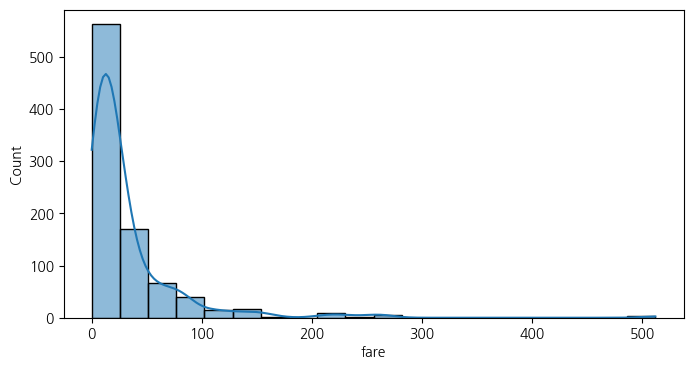

In [81]:
# df["fare"] 정규분포 시각화
sns.histplot(data=df, x='fare', bins=20, kde=True)
plt.show()

In [82]:
#@title 정답 확인 { display-mode: "form" }
age_mean = titanic["age"].mean()
age_median = titanic["age"].median()
fare_max = titanic["fare"].max()

fare_mean = titanic["fare"].mean()
fare_median = titanic["fare"].median()

print(f"age 평균: {age_mean:.1f}")
print(f"age 중앙값: {age_median:.1f}")
print(f"fare 최댓값: {fare_max:.1f}")
print(f"fare 평균: {fare_mean:.1f}")
print(f"fare 중앙값: {fare_median:.1f}")
print("해석: fare는 평균이 중앙값보다 크므로 오른쪽 꼬리가 긴 분포로 예상할 수 있습니다.")


age 평균: 29.7
age 중앙값: 28.0
fare 최댓값: 512.3
fare 평균: 32.2
fare 중앙값: 14.5
해석: fare는 평균이 중앙값보다 크므로 오른쪽 꼬리가 긴 분포로 예상할 수 있습니다.


### 3.3 응용 실습: EDA 보고 함수 만들기

어떤 데이터프레임에도 사용할 수 있는 `eda_report(df)` 함수를 작성한다.

#### 출력 항목

① 행과 열의 수 ?!<br> 
① 행과 열의 수<br>
② 결측치가 있는 열과 결측 비율<br>
③ 중복 행 수<br>
④ 수치형 변수의 요약 통계


In [83]:
def eda_report(df):
    # TODO: 위 4개 항목을 print 하세요
    print(f"1. 행: {df.shape[0]}, 열:{df.shape[1]}")

    missing_rate = df.isna().mean().mul(100).round(1)
    missing_rate = missing_rate[missing_rate > 0].sort_values()
    print(f"2. 결측치 비율: {missing_rate}")

    duplu = df.duplicated().sum()
    print(f"3. 중복 행의 수 {duplu}")
    df.describe().round(2)
eda_report(titanic)   # 작성 후 tips, iris 에도 적용해 보세요


1. 행: 891, 열:15
2. 결측치 비율: embarked        0.2
embark_town     0.2
age            19.9
deck           77.2
dtype: float64
3. 중복 행의 수 107


In [84]:
#@title 정답 확인 { display-mode: "form" }
def eda_report(df):
    print(f"행과 열: {df.shape[0]:,}행, {df.shape[1]}열")

    missing_rate = df.isna().mean().mul(100).round(1)
    missing_rate = missing_rate[missing_rate > 0].sort_values(ascending=False)

    print("\n결측치 비율")
    if missing_rate.empty:
        print("결측치가 없습니다.")
    else:
        print(missing_rate.to_string())

    print(f"\n중복 행: {df.duplicated().sum()}건")
    print("\n수치형 변수 요약")
    display(df.describe().round(2))

eda_report(titanic)


행과 열: 891행, 15열

결측치 비율
deck           77.2
age            19.9
embarked        0.2
embark_town     0.2

중복 행: 107건

수치형 변수 요약


,survived,pclass,age,sibsp,parch,fare
count,891.00,891.00,714.00,891.00,891.00,891.00
mean,0.38,2.31,29.70,0.52,0.38,32.20
std,0.49,0.84,14.53,1.10,0.81,49.69
min,0.00,1.00,0.42,0.00,0.00,0.00
25%,0.00,2.00,20.12,0.00,0.00,7.91
50%,0.00,3.00,28.00,0.00,0.00,14.45
75%,1.00,3.00,38.00,1.00,0.00,31.00
max,1.00,3.00,80.00,8.00,6.00,512.33


### 3.4 심화 실습: Anscombe 데이터 확인

Anscombe 데이터는 네 집단의 평균, 분산, 상관계수가 거의 같지만 산점도 모양은 서로 다르다. 요약 통계만으로 데이터의 구조를 판단하기 어려운 이유를 확인한다.

#### 수행 내용

① 집단별 x 평균, x 표준편차, y 평균, y 표준편차와 상관계수를 계산한다.<br>
② 집단별 산점도와 회귀선을 그린다.<br>
③ 통계량과 그래프를 함께 해석한다.


In [85]:
ans = sns.load_dataset("anscombe")
display(ans.head(3))

# TODO 1: dataset 별 x mean/std, y mean/std, corr(x,y) 집계표 만들기
#@title 정답 확인 { display-mode: "form" }
summary = ans.groupby("dataset").agg(
    x_mean=("x", "mean"),
    x_std=("x", "std"),
    y_mean=("y", "mean"),
    y_std=("y", "std"),
)
summary["corr"] = ans.groupby("dataset").apply(
    lambda g: g["x"].corr(g["y"])
)
display(summary.round(2))


,dataset,x,y
0,I,10.0,8.04
1,I,8.0,6.95
2,I,13.0,7.58


/tmp/ipykernel_86026/2251888503.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary["corr"] = ans.groupby("dataset").apply(


,x_mean,x_std,y_mean,y_std,corr
dataset,,,,,
I,9.0,3.32,7.5,2.03,0.82
II,9.0,3.32,7.5,2.03,0.82
III,9.0,3.32,7.5,2.03,0.82
IV,9.0,3.32,7.5,2.03,0.82


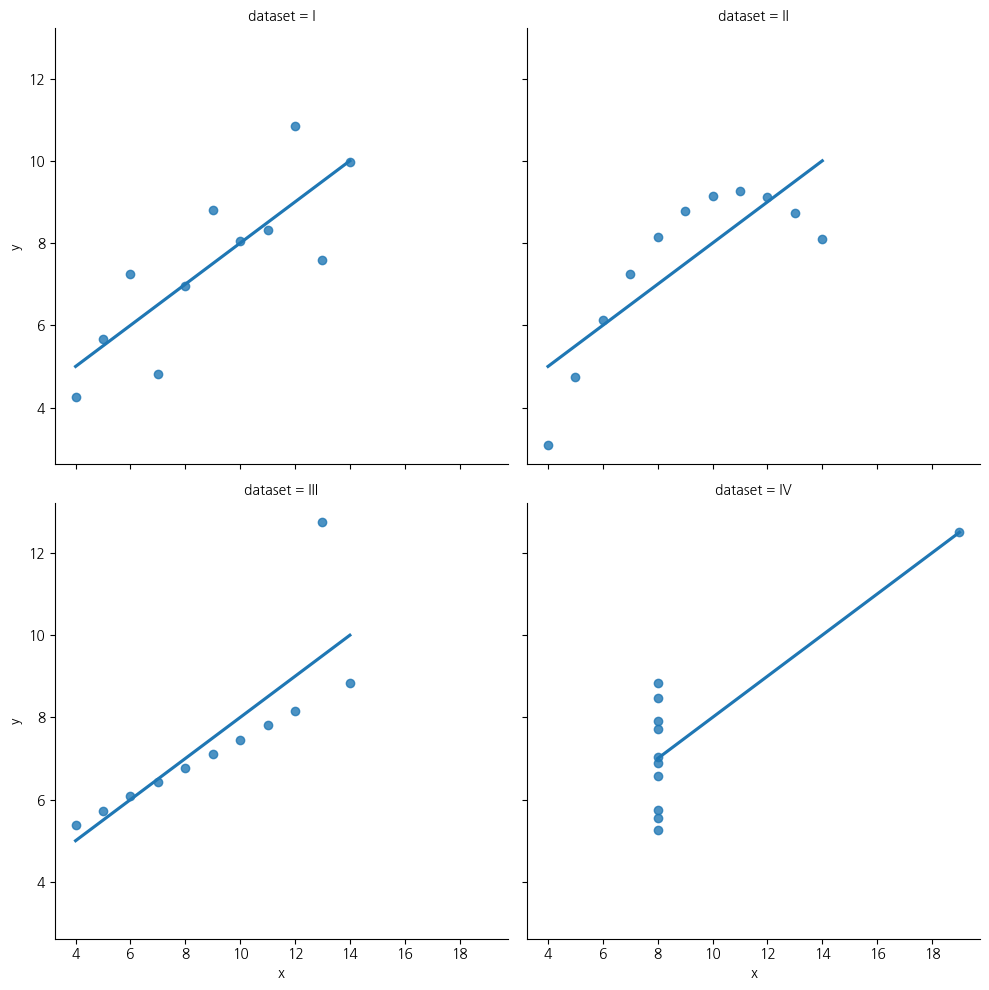

In [86]:
# TODO 2: sns.lmplot 또는 subplot 4개로 그룹별 산점도 그리기

sns.lmplot(data=ans,
           x="x",
           y="y",
           col = "dataset",
           col_wrap= 2,
           ci= None)
plt.show()

/tmp/ipykernel_86026/2870253695.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary["corr"] = ans.groupby("dataset").apply(


,x_mean,x_std,y_mean,y_std,corr
dataset,,,,,
I,9.0,3.32,7.5,2.03,0.82
II,9.0,3.32,7.5,2.03,0.82
III,9.0,3.32,7.5,2.03,0.82
IV,9.0,3.32,7.5,2.03,0.82


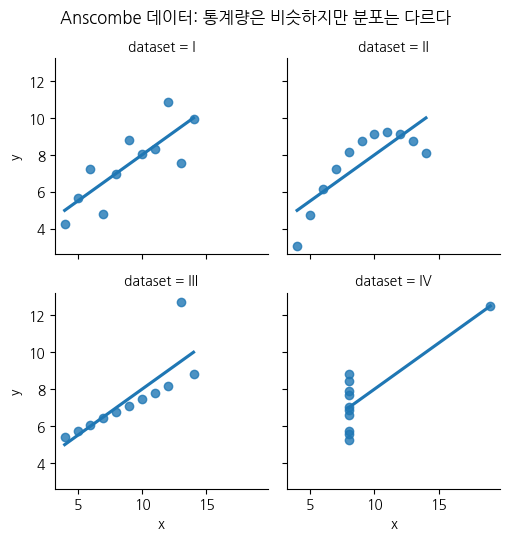

해석: 요약 통계와 상관계수는 반드시 그래프와 함께 확인해야 합니다.


In [87]:
#@title 정답 확인 { display-mode: "form" }
summary = ans.groupby("dataset").agg(
    x_mean=("x", "mean"),
    x_std=("x", "std"),
    y_mean=("y", "mean"),
    y_std=("y", "std"),
)
summary["corr"] = ans.groupby("dataset").apply(
    lambda g: g["x"].corr(g["y"])
)
display(summary.round(2))

g = sns.lmplot(
    data=ans,
    x="x",
    y="y",
    col="dataset",
    col_wrap=2,
    height=2.6,
    ci=None,
)
g.fig.suptitle("Anscombe 데이터: 통계량은 비슷하지만 분포는 다르다", y=1.03)
plt.show()

print("해석: 요약 통계와 상관계수는 반드시 그래프와 함께 확인해야 합니다.")


## 4. 중심을 나타내는 통계량

| 통계량 | 의미 | 특징 |
|---|---|---|
| 평균 | 전체 합을 개수로 나눈 값 | 이상치의 영향을 크게 받는다 |
| 중앙값 | 정렬했을 때 가운데에 위치한 값 | 이상치의 영향을 적게 받는다 |
| 최빈값 | 가장 자주 나타나는 값 | 범주형 변수의 대표값으로 사용할 수 있다 |

이상치가 있거나 분포가 한쪽으로 치우치면 평균과 중앙값을 함께 확인한다.


In [88]:
# 이상치 79가 평균과 중앙값에 미치는 영향을 비교합니다.
x = [1, 2, 2, 3, 4, 7, 15]
y = x + [79]                                  # outlier 추가

print(f"평균   : {np.mean(x):5.2f} -> {np.mean(y):5.2f}   (4.86 -> 14.13, 민감 )")
print(f"중앙값 : {np.median(x):5.2f} -> {np.median(y):5.2f}   (3 -> 3.5, 강건 )")


평균   :  4.86 -> 14.12   (4.86 -> 14.13, 민감 )
중앙값 :  3.00 ->  3.50   (3 -> 3.5, 강건 )


### 4.1 기초 실습: 중앙값 직접 계산하기

`y = [1, 2, 2, 3, 4, 7, 15, 79]`의 중앙값을 `np.median()` 없이 계산한다.

#### 수행 절차

① 데이터를 정렬한다.<br>
② 데이터 개수가 짝수인지 확인한다.<br>
③ 가운데 두 값의 평균을 계산한다.<br>
④ `np.median()` 결과와 비교한다.


In [89]:
y = [1, 2, 2, 3, 4, 7, 15, 79]

# TODO: 정렬 -> 가운데 두 값의 평균 (np.median 금지!)
# 1
sorted_y = sorted(y)
# 2
n = len(sorted_y)
print(n)
# 3
manual_median = (sorted_y[n//2 - 1] + sorted_y[n//2]) / 2
# 4
print(manual_median, "==", np.median(y), "?")


8
3.5 == 3.5 ?


In [90]:
#@title 정답 확인 { display-mode: "form" }
y_sorted = sorted(y)
n = len(y_sorted)
# n이 짝수 -> 가운데 두 값 index는 n//2 - 1 과 n//2  (0부터 세기 때문)
manual_median = (y_sorted[n//2 - 1] + y_sorted[n//2]) / 2   # (3 + 4) / 2 = 3.5

print(f"수작업 중앙값 {manual_median} == np.median {np.median(y)} -> {manual_median == np.median(y)}")
# 통계 공식은 1부터 세지만 파이썬 인덱스는 0부터 시작합니다.


수작업 중앙값 3.5 == np.median 3.5 -> True


### 4.2 응용 실습: 평균 연봉 해석하기

직원 20명의 연봉 데이터에 고액 연봉자 한 명이 포함되어 있다.

#### 수행 내용

① 평균과 중앙값을 계산한다.<br>
② 히스토그램에 평균선과 중앙값을 표시한다.<br>
③ 평균 연봉만 제시할 때 발생하는 해석상의 문제를 한 문장으로 정리한다.


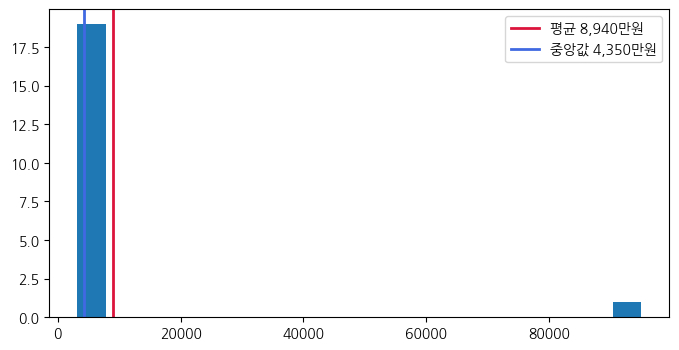

In [91]:
salary = np.array([3200, 3400, 3500, 3600, 3800, 3900, 4000, 4100, 4200, 4300,
                   4400, 4500, 4600, 4800, 5000, 5200, 5500, 5800, 6000, 95000])  # <- CEO

# TODO: 평균/중앙값 계산 + 히스토그램에 두 선 표시
mean, median = salary.mean(), np.median(salary)
plt.hist(salary,bins=20)
plt.axvline(mean,   color="crimson",   lw=2, label=f"평균 {mean:,.0f}만원")
plt.axvline(median, color="royalblue", lw=2, label=f"중앙값 {median:,.0f}만원")
plt.legend()
plt.show()

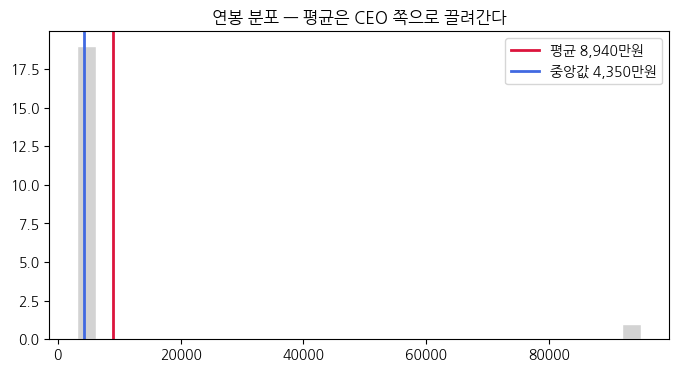

평균 8,940 vs 중앙값 4,350 -> 격차 4,590만원
답: 상위 1명의 극단값이 평균을 끌어올려, '보통 직원'의 연봉을 대표하지 못함
   -> right-skewed 소득 데이터의 대표값은 중앙값이 정직하다


In [92]:
#@title 정답 확인 { display-mode: "form" }
m, med = salary.mean(), np.median(salary)

plt.hist(salary, bins=30, color="lightgray", edgecolor="white")
plt.axvline(m,   color="crimson",   lw=2, label=f"평균 {m:,.0f}만원")
plt.axvline(med, color="royalblue", lw=2, label=f"중앙값 {med:,.0f}만원")
plt.legend(); plt.title("연봉 분포 — 평균은 CEO 쪽으로 끌려간다")
plt.show()

print(f"평균 {m:,.0f} vs 중앙값 {med:,.0f} -> 격차 {m-med:,.0f}만원")
print("답: 상위 1명의 극단값이 평균을 끌어올려, '보통 직원'의 연봉을 대표하지 못함")
print("   -> right-skewed 소득 데이터의 대표값은 중앙값이 정직하다")


### 4.3 심화 실습: 절사평균과 가중평균

평균과 중앙값 외에도 목적에 따라 절사평균과 가중평균을 사용한다.

- 절사평균: 양쪽 극단값 일부를 제거한 뒤 계산한 평균
- 가중평균: 값마다 다른 중요도를 적용한 평균

#### 수행 내용

① 연봉 데이터의 10% 절사평균을 직접 계산한다.<br>
② `scipy.stats.trim_mean()` 결과와 비교한다.<br>
③ 평균, 절사평균, 중앙값을 비교한다.<br>
④ 과목별 학점을 반영한 가중평균 GPA를 계산한다.


In [105]:
# TODO 1: 정렬 -> 상,하위 10% 제거 -> 평균  (n=20이므로 양끝 2개씩 제거)
salary = sorted(salary)
df = pd.DataFrame({'values': salary})
df


,values
0,3200
1,3400
2,3500
3,3600
4,3800
5,3900
6,4000
7,4100
8,4200
9,4300


In [106]:
lower_boundary = df['values'].quantile(0.10)
upper_boundary = df['values'].quantile(0.90)
trimmed_mean = df[(df['values'] >= lower_boundary) & (df['values'] <=upper_boundary)]['values'].mean()
print("수작업: ",trimmed_mean)

수작업:  4450.0


In [108]:
# TODO 2: scipy 결과와 대조
from scipy.stats import trim_mean
trimmed_scipy = trim_mean(salary, proportiontocut=0.1)
print("라이브러리: ",trimmed_scipy)
s = df['values'].mean()
print("평균",s)

# TODO 3: GPA 가중평균
grade = np.array([4.0, 3.5, 4.5])
credits = np.array([3,2,1])
gpa = np.average(grade, weights=credits)
print(f"GPA = {gpa}, {grade.mean()}")


라이브러리:  4450.0
평균 8940.0
GPA = 3.9166666666666665, 4.0


In [ ]:
#@title 정답 확인 { display-mode: "form" }
from scipy.stats import trim_mean

# ── 1) 절사평균 직접 구현 ─────────────────────────────
# proportiontocut=0.1 -> '각' 꼬리에서 10%씩 제거 (양쪽 합 20%)
s = np.sort(salary)
k = int(len(s) * 0.1)                 # 20 × 0.1 = 2개
trimmed_manual = s[k:-k].mean()       # 하위 2개 + 상위 2개(CEO 포함) 제외

trimmed_scipy = trim_mean(salary, proportiontocut=0.1)
assert np.isclose(trimmed_manual, trimmed_scipy), "구현 검증 실패!"

print(f"평균        : {salary.mean():>9,.1f}  <- CEO에 끌려감")
print(f"10% 절사평균: {trimmed_manual:>9,.1f}  <- 극단값 제거 후 '건강한 평균'")
print(f"중앙값      : {np.median(salary):>9,.1f}  <- 가장 강건하지만 정보 손실도 최대")
#  절사평균은 평균(정보 활용↑)과 중앙값(강건성↑) 사이의 트레이드오프 지점.
#    올림픽 심판 채점, 국가 통계의 '평균 소득' 보정 등에서 실제 사용

# ── 3) 가중평균 : Σ(값×가중치) / Σ(가중치) ──────────────
grades  = np.array([4.5, 3.5, 4.0])
credits = np.array([3,   2,   1  ])
gpa = np.average(grades, weights=credits)     # (4.5*3 + 3.5*2 + 4*1) / 6
print(f"\nGPA = {gpa:.3f}  (단순평균 {grades.mean():.3f}과 다름 — 3학점 과목이 더 무겁다)")


평균        :   8,940.0  <- CEO에 끌려감
10% 절사평균:   4,450.0  <- 극단값 제거 후 '건강한 평균'
중앙값      :   4,350.0  <- 가장 강건하지만 정보 손실도 최대

GPA = 4.083  (단순평균 4.000과 다름 — 3학점 과목이 더 무겁다)


## 5. 퍼짐을 나타내는 통계량

| 통계량 | 의미 |
|---|---|
| 편차 | 관측값에서 평균을 뺀 값 |
| 분산 | 편차 제곱의 평균 |
| 표준편차 | 분산의 제곱근 |
| 변이계수 | 표준편차를 평균으로 나눈 값 |
| 범위 | 최댓값에서 최솟값을 뺀 값 |

표준편차는 원래 변수와 같은 단위를 사용한다.<br> 단위나 평균 규모가 다른 변수의 상대적 변동성을 비교할 때는 변이계수를 사용한다.


평균: 175.2 | 표준편차: 3.76


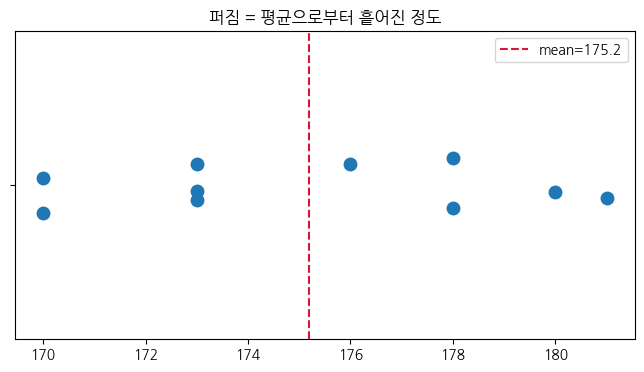

In [ ]:
# 키 데이터의 평균과 표준편차를 확인합니다.
height = np.array([170, 170, 173, 173, 173, 176, 178, 178, 180, 181])
print("평균:", height.mean(), "| 표준편차:", round(height.std(), 2))
sns.stripplot(x=height, size=10)
plt.axvline(height.mean(), color="crimson", ls="--", label=f"mean={height.mean():.1f}")
plt.legend(); plt.title("퍼짐 = 평균으로부터 흩어진 정도"); plt.show()


### 5.1 기초 실습: 분산과 표준편차 직접 계산하기

`height` 데이터로 편차, 편차 제곱, 분산, 표준편차와 변이계수를 순서대로 계산한다. `mean()`을 제외한 통계 함수는 사용하지 않는다.

#### 확인 값

- 분산: 약 14.16
- 표준편차: 약 3.76
- 변이계수: 약 0.021


In [ ]:
mean_h = height.mean()   # 175.2

# TODO: 순서대로 계산
dev      = height - mean_h          # 편차
dev_sq   = dev ** 2           # 편차 제곱
var      = dev_sq.sum() /len(height)           # 분산 = 편차²의 합 / 관측값 수
std      = var ** 0.5           # 표준편차 = 분산 ** 0.5
cv       = std / mean_h           # 변이계수 = 표준편차 / 평균
print(var, std, cv)


14.16 3.7629775444453557 0.02147818233130911


In [ ]:
#@title 정답 확인 { display-mode: "form" }
mean_h = height.mean()                       # 175.2
dev    = height - mean_h                     # 편차 : 합은 반드시 0 (검증해 보세요)
dev_sq = dev ** 2                            # 제곱으로 부호 제거
var    = dev_sq.sum() / len(height)          # 분산 14.16, n으로 나누는 모분산 방식
std    = var ** 0.5                          # 표준편차 3.76
cv     = std / mean_h                        # 변이계수 0.021

print(f"편차 합 = {dev.sum():.10f}  <- 항상 0")
print(f"분산 {var:.2f} | 표준편차 {std:.2f} | 변이계수 {cv:.3f}")
print("numpy 검증:", round(height.var(), 2), round(height.std(), 2))  # ddof=0 기본


편차 합 = 0.0000000000  <- 항상 0
분산 14.16 | 표준편차 3.76 | 변이계수 0.021
numpy 검증: 14.16 3.76


### 5.2 응용 실습: 변이계수로 변동성 비교하기

일별 방문객 수와 일 매출은 단위와 평균 규모가 다르다.

#### 수행 내용

① 두 변수의 평균과 표준편차를 계산한다.<br>
② 표준편차를 직접 비교하기 어려운 이유를 설명한다.<br>
③ 변이계수를 계산해 상대적으로 더 불안정한 변수를 판단한다.


In [ ]:
visitors = np.random.normal(500,  60,  30).round()     # 명 단위
sales    = np.random.normal(3000, 250, 30).round()     # 만원 단위

# TODO: 표준편차 비교 -> 변이계수 비교
for name, v in [("방문객(명)", visitors), ("매출(만원)", sales)]:
    print(f"{name:>8} | 평균 {v.mean():7.1f} | 표준편차 {v.std():6.1f} | CV {v.std()/v.mean():.3f}")

  방문객(명) | 평균   476.0 | 표준편차   54.2 | CV 0.114
  매출(만원) | 평균  2987.3 | 표준편차  209.1 | CV 0.070


In [ ]:
#@title 정답 확인 { display-mode: "form" }
for name, v in [("방문객(명)", visitors), ("매출(만원)", sales)]:
    print(f"{name:>8} | 평균 {v.mean():7.1f} | 표준편차 {v.std():6.1f} | CV {v.std()/v.mean():.3f}")

#  표준편차: 매출(≈250) ≫ 방문객(≈60) 이지만, 이는 '만원'과 '명'이라는
# 측정 단위와 규모가 다르므로 표준편차를 직접 비교하기 어렵습니다.
#    변이계수(단위 소거): 방문객 ≈ 0.12 > 매출 ≈ 0.08
#    -> 상대적 변동성은 '방문객'이 더 크다. 즉 손님 수가 더 들쭉날쭉!


  방문객(명) | 평균   476.0 | 표준편차   54.2 | CV 0.114
  매출(만원) | 평균  2987.3 | 표준편차  209.1 | CV 0.070


### 5.3 심화 실습: 모분산과 표본분산 비교하기

NumPy의 `var(ddof=0)`은 n으로 나누고 `var(ddof=1)`은 n-1로 나눈다. 표본으로 모집단의 분산을 추정할 때는 n-1을 사용하는 이유를 시뮬레이션으로 확인한다.

#### 실험 조건

- 모집단 분산: 25
- 표본 크기: 5
- 반복 횟수: 10,000회

각 방식으로 계산한 분산의 평균이 실제 모집단 분산과 얼마나 가까운지 비교한다.


In [98]:
TRUE_VAR, N, TRIALS = 25, 5, 10_000

# TODO: 반복 추출 -> 두 방식으로 분산 계산 -> 평균 비교
vars_n, vars_n1 = [], []
for _ in range(TRIALS):
    sample = np.random.normal(0, TRUE_VAR**0.5, N)
    vars_n .append(sample.var(ddof=0))    # ÷ n     : 관측한 표본 '자체'의 분산
    vars_n1.append(sample.var(ddof=1))    # ÷ (n-1) : 모분산의 '불편추정량'

print(f"진짜 모분산          : {TRUE_VAR}")
print(f"÷n     추정 평균     : {np.mean(vars_n):.2f}   <- 체계적 과소평가 (편향)")
print(f"÷(n-1) 추정 평균     : {np.mean(vars_n1):.2f}   <- 25에 근접 (불편추정량 )")

#  직관 : 표본 5개의 편차는 '표본평균'을 기준으로 잰다.
#  표본평균은 항상 표본 데이터 한가운데 위치 -> 진짜 모평균 기준보다
#  편차가 작게 측정될 수밖에 없음 -> 그 손실분을 (n-1)로 나눠 보정.
#  이론적으로 E[÷n 추정치] = σ² × (n-1)/n = 25 × 0.8 = 20 (위 결과와 일치!)
print(f"이론값 25 × (n-1)/n = {TRUE_VAR * (N-1)/N}")

진짜 모분산          : 25
÷n     추정 평균     : 19.96   <- 체계적 과소평가 (편향)
÷(n-1) 추정 평균     : 24.95   <- 25에 근접 (불편추정량 )
이론값 25 × (n-1)/n = 20.0


In [ ]:
#@title 정답 확인 { display-mode: "form" }
TRUE_VAR, N, TRIALS = 25, 5, 10_000

vars_n, vars_n1 = [], []
for _ in range(TRIALS):
    sample = np.random.normal(0, TRUE_VAR**0.5, N)
    vars_n .append(sample.var(ddof=0))    # ÷ n     : 관측한 표본 '자체'의 분산
    vars_n1.append(sample.var(ddof=1))    # ÷ (n-1) : 모분산의 '불편추정량'

print(f"진짜 모분산          : {TRUE_VAR}")
print(f"÷n     추정 평균     : {np.mean(vars_n):.2f}   <- 체계적 과소평가 (편향)")
print(f"÷(n-1) 추정 평균     : {np.mean(vars_n1):.2f}   <- 25에 근접 (불편추정량 )")

#  직관 : 표본 5개의 편차는 '표본평균'을 기준으로 잰다.
#  표본평균은 항상 표본 데이터 한가운데 위치 -> 진짜 모평균 기준보다
#  편차가 작게 측정될 수밖에 없음 -> 그 손실분을 (n-1)로 나눠 보정.
#  이론적으로 E[÷n 추정치] = σ² × (n-1)/n = 25 × 0.8 = 20 (위 결과와 일치!)
print(f"이론값 25 × (n-1)/n = {TRUE_VAR * (N-1)/N}")


진짜 모분산          : 25
÷n     추정 평균     : 20.08   <- 체계적 과소평가 (편향)
÷(n-1) 추정 평균     : 25.10   <- 25에 근접 (불편추정량 )
이론값 25 × (n-1)/n = 20.0


## 6. 사분위수, IQR과 왜도

| 개념 | 설명 |
|---|---|
| Q1 | 데이터의 25% 지점 |
| Q2 | 데이터의 50% 지점, 중앙값 |
| Q3 | 데이터의 75% 지점 |
| IQR | Q3에서 Q1을 뺀 값 |
| 왜도 | 분포가 한쪽으로 치우친 정도 |
| 박스플롯 | 중앙값, 사분위수, 퍼짐과 이상치 후보를 함께 표시하는 그래프 |

IQR 기준의 이상치 후보 범위는 `Q1 - 1.5 × IQR`부터 `Q3 + 1.5 × IQR`까지이다. 통계 기준으로 찾은 값은 업무 맥락에서 다시 확인해야 한다.


Q1=173.0 | Q2(중앙값)=174.5 | Q3=178.0 | IQR=5.0
하한선 = Q1 - 1.5×IQR = 165.5 | 상한선 = Q3 + 1.5×IQR = 185.5


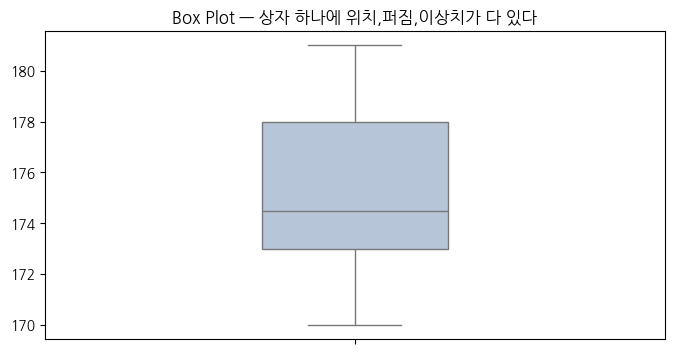

In [ ]:
# 키 데이터의 사분위수와 박스플롯을 확인합니다.
q1, q2, q3 = np.percentile(height, [25, 50, 75])
iqr = q3 - q1
print(f"Q1={q1} | Q2(중앙값)={q2} | Q3={q3} | IQR={iqr}")
print(f"하한선 = Q1 - 1.5×IQR = {q1 - 1.5*iqr} | 상한선 = Q3 + 1.5×IQR = {q3 + 1.5*iqr}")

sns.boxplot(y=height, width=0.3, color="lightsteelblue")
plt.title("Box Plot — 상자 하나에 위치,퍼짐,이상치가 다 있다"); plt.show()


### 6.1 기초 실습: IQR 이상치 후보 찾기

`titanic` 데이터의 `fare` 변수에서 다음 값을 계산한다.

① Q1과 Q3<br>
② IQR<br>
③ 이상치 후보의 하한선과 상한선<br>
④ 범위를 벗어난 값의 개수


In [ ]:
fare = titanic["fare"].dropna()

# TODO
q1, q3 = fare.quantile([0.25, 0.75])
iqr    =  q3 - q1
lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
n_outliers = ((fare < lower) | (fare > upper)).sum()
print(f"이상치 후보: {n_outliers}건")


이상치 후보: 116건


In [ ]:
#@title 정답 확인 { display-mode: "form" }
fare = titanic["fare"].dropna()
q1, q3 = fare.quantile([0.25, 0.75])
iqr    = q3 - q1
lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
n_outliers = ((fare < lower) | (fare > upper)).sum()

print(f"Q1={q1:.1f}, Q3={q3:.1f}, IQR={iqr:.1f}")
print(f"정상 범위 [{lower:.1f}, {upper:.1f}] 밖 = {n_outliers}건 ({n_outliers/len(fare):.1%})")
#  fare 는 right-skewed -> 이상치가 전부 '위쪽'에 몰려 있음. boxplot으로 확인해 보세요


Q1=7.9, Q3=31.0, IQR=23.1
정상 범위 [-26.7, 65.6] 밖 = 116건 (13.0%)


### 6.2 응용 실습: 이상치 탐지 함수 만들기

`detect_outliers(series, k=1.5)` 함수를 작성한다.

#### 반환값

`이상치 데이터, 하한선, 상한선`

`tips["total_bill"]`에 적용하고 `k=1.5`와 `k=3.0`의 결과를 비교한다.


In [ ]:

def detect_outliers(s, k=1.5):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - k*iqr, q3 + k*iqr
    return s[(s < lower) | (s > upper)], lower, upper

for k in (1.5, 3.0):
    out, lo, up = detect_outliers(tips["total_bill"], k)
    tag = "일반 기준" if k == 1.5 else "극단 기준"
    print(f"k={k} ({tag}) | 범위 [{lo:.1f}, {up:.1f}] | 이상치 {len(out)}건")

k=1.5 (일반 기준) | 범위 [-2.8, 40.3] | 이상치 9건
k=3.0 (극단 기준) | 범위 [-19.0, 56.5] | 이상치 0건


In [ ]:
#@title 정답 확인 { display-mode: "form" }
def detect_outliers(s, k=1.5):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - k*iqr, q3 + k*iqr
    return s[(s < lower) | (s > upper)], lower, upper

for k in (1.5, 3.0):
    out, lo, up = detect_outliers(tips["total_bill"], k)
    tag = "일반 기준" if k == 1.5 else "극단 기준"
    print(f"k={k} ({tag}) | 범위 [{lo:.1f}, {up:.1f}] | 이상치 {len(out)}건")

#  k는 '민감도 다이얼' — 1.5는 관례일 뿐 절대 법칙이 아님.
# 통계 기준으로 찾은 값은 업무적으로 정상인지 다시 확인해야 합니다.


k=1.5 (일반 기준) | 범위 [-2.8, 40.3] | 이상치 9건
k=3.0 (극단 기준) | 범위 [-19.0, 56.5] | 이상치 0건


### 6.3 심화 실습: 왜도와 로그 변환

오른쪽 꼬리가 긴 양수 데이터는 로그 변환 후 대칭에 가까워질 수 있다.

#### 수행 내용

① `titanic["fare"]`에서 0보다 큰 값만 선택한다.<br>
② 변환 전 왜도를 계산한다.<br>
③ 로그 변환 후 왜도를 계산한다.<br>
④ 변환 전과 후의 히스토그램을 비교한다.<br>
⑤ 왜도의 절댓값으로 변환 필요 여부를 판단하는 함수를 작성한다.


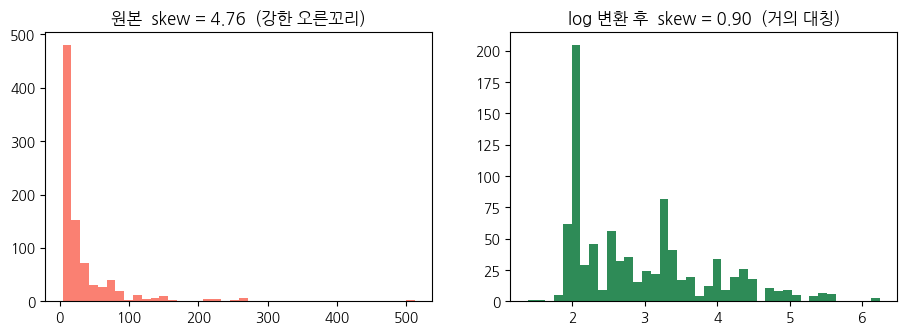

skew=+4.76 -> 변환 권장 
skew=+0.90 -> 변환 불필요 


np.False_

In [109]:
fare_pos = titanic.loc[titanic["fare"] > 0, "fare"]
fare_pos
from scipy.stats import skew

fare_pos = titanic.loc[titanic["fare"] > 0, "fare"]   # log(0) = -inf 방지 위해 0 제외
fare_log = np.log(fare_pos)

sk_before, sk_after = skew(fare_pos), skew(fare_log)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].hist(fare_pos, bins=40, color="salmon")
axes[0].set_title(f"원본  skew = {sk_before:.2f}  (강한 오른꼬리)")
axes[1].hist(fare_log, bins=40, color="seagreen")
axes[1].set_title(f"log 변환 후  skew = {sk_after:.2f}  (거의 대칭)")
plt.show()

def needs_transform(s, threshold=1.0):
    """|왜도| ≥ threshold 이면 분포 변환 권장.
    관례적 해석: |skew| < 0.5 대칭 / 0.5~1 중간 / ≥ 1 심한 비대칭"""
    sk = skew(s.dropna())
    verdict = abs(sk) >= threshold
    print(f"skew={sk:+.2f} -> 변환 {'권장 ' if verdict else '불필요 '}")
    return verdict

needs_transform(fare_pos)      # 권장
needs_transform(fare_log)  

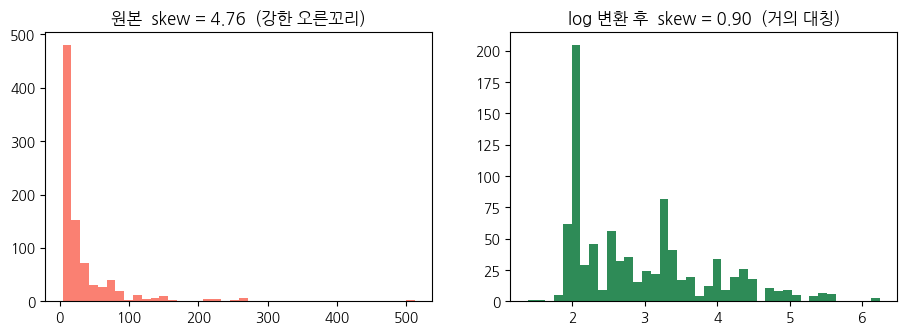

skew=+4.76 -> 변환 권장 
skew=+0.90 -> 변환 불필요 


np.False_

In [110]:
#@title 정답 확인 { display-mode: "form" }
from scipy.stats import skew

fare_pos = titanic.loc[titanic["fare"] > 0, "fare"]   # log(0) = -inf 방지 위해 0 제외
fare_log = np.log(fare_pos)

sk_before, sk_after = skew(fare_pos), skew(fare_log)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].hist(fare_pos, bins=40, color="salmon")
axes[0].set_title(f"원본  skew = {sk_before:.2f}  (강한 오른꼬리)")
axes[1].hist(fare_log, bins=40, color="seagreen")
axes[1].set_title(f"log 변환 후  skew = {sk_after:.2f}  (거의 대칭)")
plt.show()

def needs_transform(s, threshold=1.0):
    """|왜도| ≥ threshold 이면 분포 변환 권장.
    관례적 해석: |skew| < 0.5 대칭 / 0.5~1 중간 / ≥ 1 심한 비대칭"""
    sk = skew(s.dropna())
    verdict = abs(sk) >= threshold
    print(f"skew={sk:+.2f} -> 변환 {'권장 ' if verdict else '불필요 '}")
    return verdict

needs_transform(fare_pos)      # 권장
needs_transform(fare_log)      # 불필요
#  로그변환의 본질 : '곱셈 세계'(배수로 커지는 데이터: 소득, 매출, 조회수)를
#    '덧셈 세계'로 옮기는 것. 그래서 경제,비즈니스 데이터에 특히 잘 듣는다


## 7. 확률분포와 표준정규분포

정규분포는 평균을 중심으로 좌우가 대칭인 분포이다.<br> 표준정규분포는 평균이 0이고 표준편차가 1인 정규분포이다.

표준점수는 관측값이 평균에서 표준편차 몇 개만큼 떨어져 있는지 나타낸다.

\[
Z =
rac{x - 	ext{평균}}{	ext{표준편차}}
\]

정규분포에서는 평균을 기준으로 약 68%가 1표준편차 안에, 약 95%가 2표준편차 안에, 약 99.7%가 3표준편차 안에 위치한다.


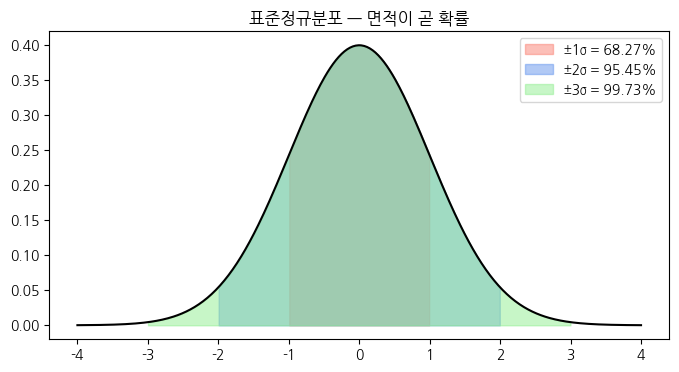

In [111]:
# ── 시연 : 정규분포 곡선과 68-95-99.7 규칙 ──────────────────
xs = np.linspace(-4, 4, 400)
ys = stats.norm.pdf(xs)

plt.plot(xs, ys, "k")
for s, c, pct in [(1, "salmon", "68.27%"), (2, "cornflowerblue", "95.45%"), (3, "lightgreen", "99.73%")]:
    plt.fill_between(xs, ys, where=(abs(xs) <= s), color=c, alpha=0.5, label=f"±{s}σ = {pct}")
plt.legend(); plt.title("표준정규분포 — 면적이 곧 확률"); plt.show()


### 7.1 기초 실습: 표준점수 비교하기

학생 A의 수학 점수와 국어 점수는 모두 90점이다. 과목별 평균과 표준편차가 다를 때 어느 과목의 상대적 성취가 더 높은지 표준점수로 판단한다.

| 구분 | 과목 | 점수 | 평균 | 표준편차 |
|---|---|---:|---:|---:|
| 예시 1 | 수학 | 90 | 60 | 30 |
| 예시 1 | 국어 | 90 | 60 | 15 |
| 예시 2 | 수학 | 90 | 50 | 15 |
| 예시 2 | 국어 | 90 | 60 | 15 |


In [112]:
def z_score(x, mean, std):
    return (x - mean) / std

# TODO: 예시1, 예시2 각각 수학/국어 Z 비교

cases = {
    "예시1": {"수학": (90, 60, 30), "국어": (90, 60, 15)},
    "예시2": {"수학": (90, 50, 15), "국어": (90, 60, 15)},
}
for case, subjects in cases.items():
    zs = {sub: z_score(*args) for sub, args in subjects.items()}
    best = max(zs, key=zs.get)
    print(f"{case} | " + " vs ".join(f"{s} Z={z:.3f}" for s, z in zs.items()) + f"  -> {best} 승 ")

예시1 | 수학 Z=1.000 vs 국어 Z=2.000  -> 국어 승 
예시2 | 수학 Z=2.667 vs 국어 Z=2.000  -> 수학 승 


In [113]:
#@title 정답 확인 { display-mode: "form" }
def z_score(x, mean, std):
    return (x - mean) / std          # "평균에서 표준편차 몇 개만큼 떨어졌나"

cases = {
    "예시1": {"수학": (90, 60, 30), "국어": (90, 60, 15)},
    "예시2": {"수학": (90, 50, 15), "국어": (90, 60, 15)},
}
for case, subjects in cases.items():
    zs = {sub: z_score(*args) for sub, args in subjects.items()}
    best = max(zs, key=zs.get)
    print(f"{case} | " + " vs ".join(f"{s} Z={z:.3f}" for s, z in zs.items()) + f"  -> {best} 승 ")

#  같은 90점이라도 '집단 안에서의 상대적 위치'는 다르다.
# 표준점수를 사용하면 서로 다른 분포의 값을 비교할 수 있습니다.


예시1 | 수학 Z=1.000 vs 국어 Z=2.000  -> 국어 승 
예시2 | 수학 Z=2.667 vs 국어 Z=2.000  -> 수학 승 


### 7.2 응용 실습: 상위 비율 계산하기

`scipy.stats.norm`의 누적분포함수와 역누적분포함수를 사용한다.

#### 수행 내용

① Z가 1.0일 때 상위 비율을 계산한다.<br>
② Z가 2.667일 때 상위 비율을 계산한다.<br>
③ 상위 1%에 해당하는 Z 기준값을 계산한다.


In [114]:
from scipy.stats import norm
for label, z in [("예시1 수학 (Z=1.0)", 1.0), ("예시2 수학 (Z=2.667)", 2.667)]:
    top = (1 - norm.cdf(z)) * 100          # cdf(z)=하위 누적확률 -> 1-cdf = 상위 비율
    print(f"{label:<22} -> 상위 {top:.2f}%")

z_cut = norm.ppf(0.99)                     # ppf: '하위 99% 지점'의 Z = 상위 1% 커트라인
print(f"상위 1% 커트라인 Z = {z_cut:.3f}")
#  cdf(값→확률)와 ppf(확률→값)는 서로 역함수 관계.
# 1표준편차 위는 상위 약 15.87%, 2표준편차 위는 상위 약 2.28%입니다.

예시1 수학 (Z=1.0)         -> 상위 15.87%
예시2 수학 (Z=2.667)       -> 상위 0.38%
상위 1% 커트라인 Z = 2.326


In [ ]:
#@title 정답 확인 { display-mode: "form" }
from scipy.stats import norm

for label, z in [("예시1 수학 (Z=1.0)", 1.0), ("예시2 수학 (Z=2.667)", 2.667)]:
    top = (1 - norm.cdf(z)) * 100          # cdf(z)=하위 누적확률 -> 1-cdf = 상위 비율
    print(f"{label:<22} -> 상위 {top:.2f}%")

z_cut = norm.ppf(0.99)                     # ppf: '하위 99% 지점'의 Z = 상위 1% 커트라인
print(f"상위 1% 커트라인 Z = {z_cut:.3f}")
#  cdf(값→확률)와 ppf(확률→값)는 서로 역함수 관계.
# 1표준편차 위는 상위 약 15.87%, 2표준편차 위는 상위 약 2.28%입니다.


### 7.3 심화 실습: 중심극한정리 확인하기

원래 분포가 정규분포가 아니어도 표본 크기가 커지면 표본평균의 분포는 정규분포에 가까워진다.

#### 실험 방법

① 주사위를 n번 굴린 평균을 계산한다.<br>
② n을 1, 2, 5, 30으로 바꾼다.<br>
③ 각 조건을 10,000회 반복한다.<br>
④ 표본평균의 히스토그램과 이론적 정규곡선을 비교한다.


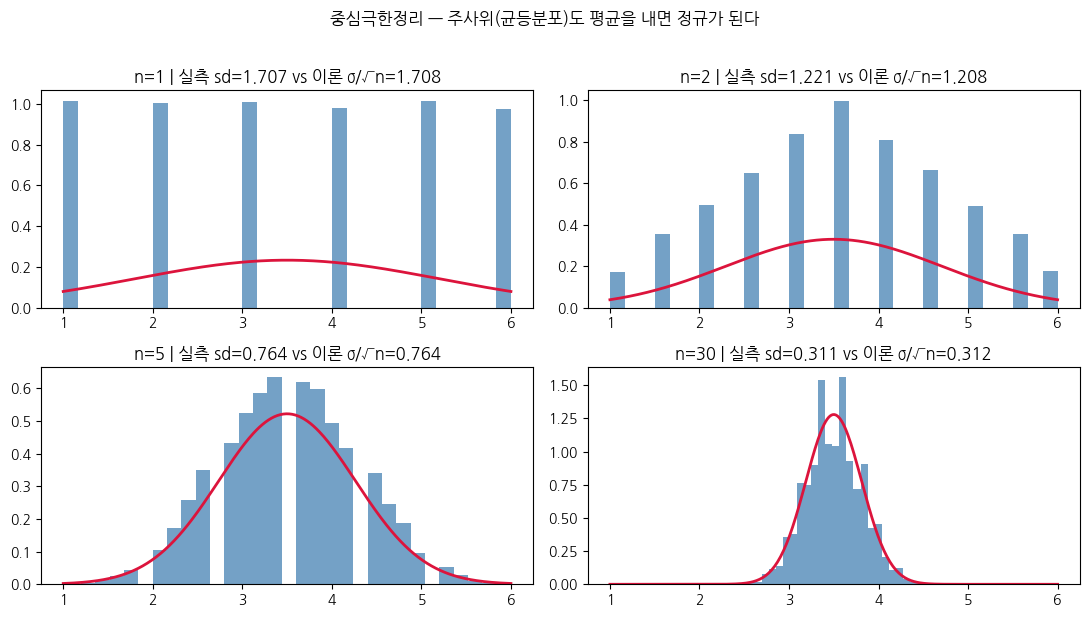

In [115]:
TRIALS = 10_000
sample_sizes = [1, 2, 5, 30]

# TODO: n별로 '주사위 n개 평균'을 TRIALS번 생성 -> 2×2 히스토그램
dice_sigma = np.std([1, 2, 3, 4, 5, 6])          # 균등분포의 σ ≈ 1.71

fig, axes = plt.subplots(2, 2, figsize=(11, 6))
for ax, n in zip(axes.ravel(), sample_sizes):
    # (TRIALS × n) 주사위를 한 번에 굴리고 행 방향 평균 -> 표본평균 TRIALS개
    means = np.random.randint(1, 7, size=(TRIALS, n)).mean(axis=1)
    ax.hist(means, bins=30, density=True, color="steelblue", alpha=0.75)

    # 이론 정규곡선 N(3.5, σ/√n) 을 겹쳐 그려 수렴 확인
    se_theory = dice_sigma / np.sqrt(n)          # 표준오차 = σ/√n
    xs = np.linspace(1, 6, 300)
    ax.plot(xs, stats.norm.pdf(xs, 3.5, se_theory), "crimson", lw=2)
    ax.set_title(f"n={n} | 실측 sd={means.std():.3f} vs 이론 σ/√n={se_theory:.3f}")

fig.suptitle("중심극한정리 — 주사위(균등분포)도 평균을 내면 정규가 된다", y=1.02)
plt.tight_layout(); plt.show()

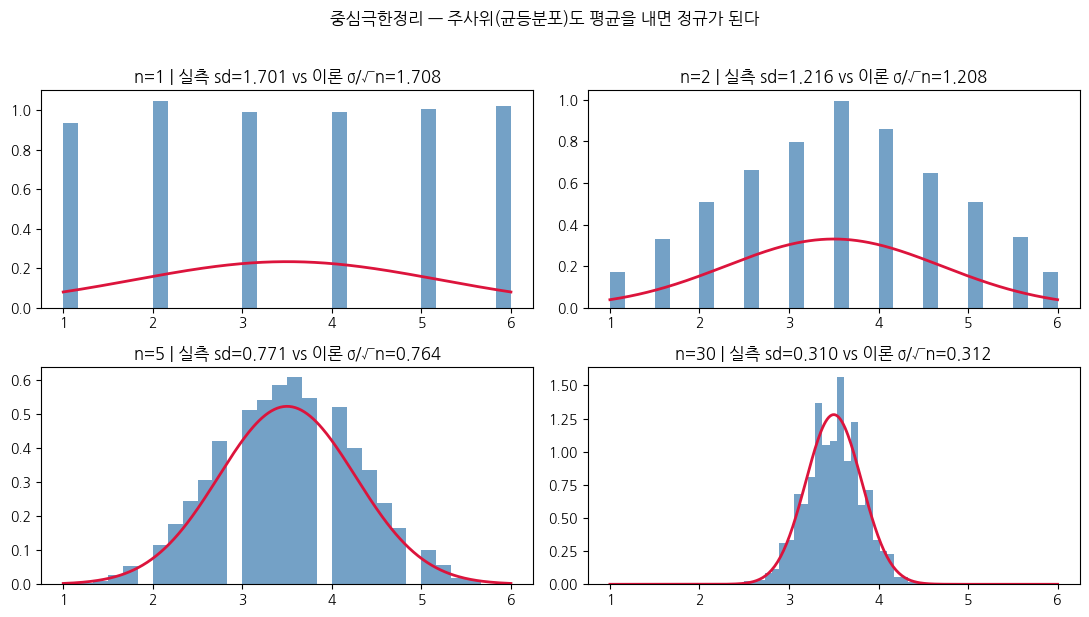

In [116]:
#@title 정답 확인 { display-mode: "form" }
TRIALS = 10_000
sample_sizes = [1, 2, 5, 30]
dice_sigma = np.std([1, 2, 3, 4, 5, 6])          # 균등분포의 σ ≈ 1.71

fig, axes = plt.subplots(2, 2, figsize=(11, 6))
for ax, n in zip(axes.ravel(), sample_sizes):
    # (TRIALS × n) 주사위를 한 번에 굴리고 행 방향 평균 -> 표본평균 TRIALS개
    means = np.random.randint(1, 7, size=(TRIALS, n)).mean(axis=1)
    ax.hist(means, bins=30, density=True, color="steelblue", alpha=0.75)

    # 이론 정규곡선 N(3.5, σ/√n) 을 겹쳐 그려 수렴 확인
    se_theory = dice_sigma / np.sqrt(n)          # 표준오차 = σ/√n
    xs = np.linspace(1, 6, 300)
    ax.plot(xs, stats.norm.pdf(xs, 3.5, se_theory), "crimson", lw=2)
    ax.set_title(f"n={n} | 실측 sd={means.std():.3f} vs 이론 σ/√n={se_theory:.3f}")

fig.suptitle("중심극한정리 — 주사위(균등분포)도 평균을 내면 정규가 된다", y=1.02)
plt.tight_layout(); plt.show()

#  읽는 법
#  n=1  : 원본 그대로 = 납작한 균등분포 (정규와 거리가 멂)
#  n=30 : 종 모양 완성 + 폭이 σ/√30 로 좁아짐
#  -> ① 모양은 정규로 수렴 ② 퍼짐은 √n 에 반비례해 축소
#  -> 'n=30이면 정규 근사 OK'라는 통계학 경험칙의 시각적 근거


## 8. 학습 정리

| 주제 | 핵심 내용 |
|---|---|
| 변수 유형 | 숫자로 표현되어도 계산 의미가 없으면 범주형일 수 있다 |
| 분석 단위 | 한 행이 무엇을 의미하는지 먼저 정의한다 |
| EDA | 구조, 결측치, 중복, 분포와 관계를 순서대로 확인한다 |
| 중심 | 이상치가 있으면 평균과 중앙값을 함께 본다 |
| 퍼짐 | 단위가 다르면 변이계수로 상대적 변동성을 비교한다 |
| 이상치 | IQR 기준은 후보를 찾는 방법이며 최종 판단은 업무 맥락에서 한다 |
| 표준점수 | 서로 다른 평균과 표준편차를 가진 값을 같은 기준으로 비교한다 |
| 중심극한정리 | 표본 크기가 커지면 표본평균의 분포가 정규분포에 가까워진다 |

### 제출 전 확인

① 모든 `TODO` 셀을 실행했는가<br>
② 오류 없이 결과가 출력되는가<br>
③ 계산 결과를 한 문장으로 해석했는가<br>
④ 심화 실습은 선택해서 수행했는가
